# Anomalous User Detection in Recommender Systems
**Approach:** MCA (Multiple Correspondence Analysis) with reconstruction-error anomaly scoring  
**Tracking:** MLflow  
**Primary metric:** AUC (Area Under ROC Curve)

## 1. Setup & Imports

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
from sklearn.manifold import TSNE

import prince
import mlflow

# ── Reproducibility ──────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Global constants ─────────────────────────────────────────────
N_ITEMS      = 1000          # fixed item universe across all weeks
RATING_CATS  = [0,1,2,3,4,5] # possible rating values
NO_INTERACT  = 6             # sentinel category for 'no interaction'

# ── MLflow ─────────────────────────────────────────────────────────
mlflow.set_tracking_uri('http://localhost:5000')
mlflow.set_experiment('Anomaly Detection')
print('Setup complete.')

Setup complete.


## 2. Data Loading

In [48]:
DATA_PATH = 'data/training_batch_with_labels.npz'   # labelled — for training & eval
SCORE_PATH = 'data/first_batch.npz'                 # unlabelled — this week's submission

# ── Load training data (labelled) ────────────────────────────────
data    = np.load(DATA_PATH, allow_pickle=True)
ratings = data['X']
labels  = data['y']

# ── Load scoring data (unlabelled) ───────────────────────────────
score_data    = np.load(SCORE_PATH, allow_pickle=True)
score_ratings = score_data['X']

## 3. EDA

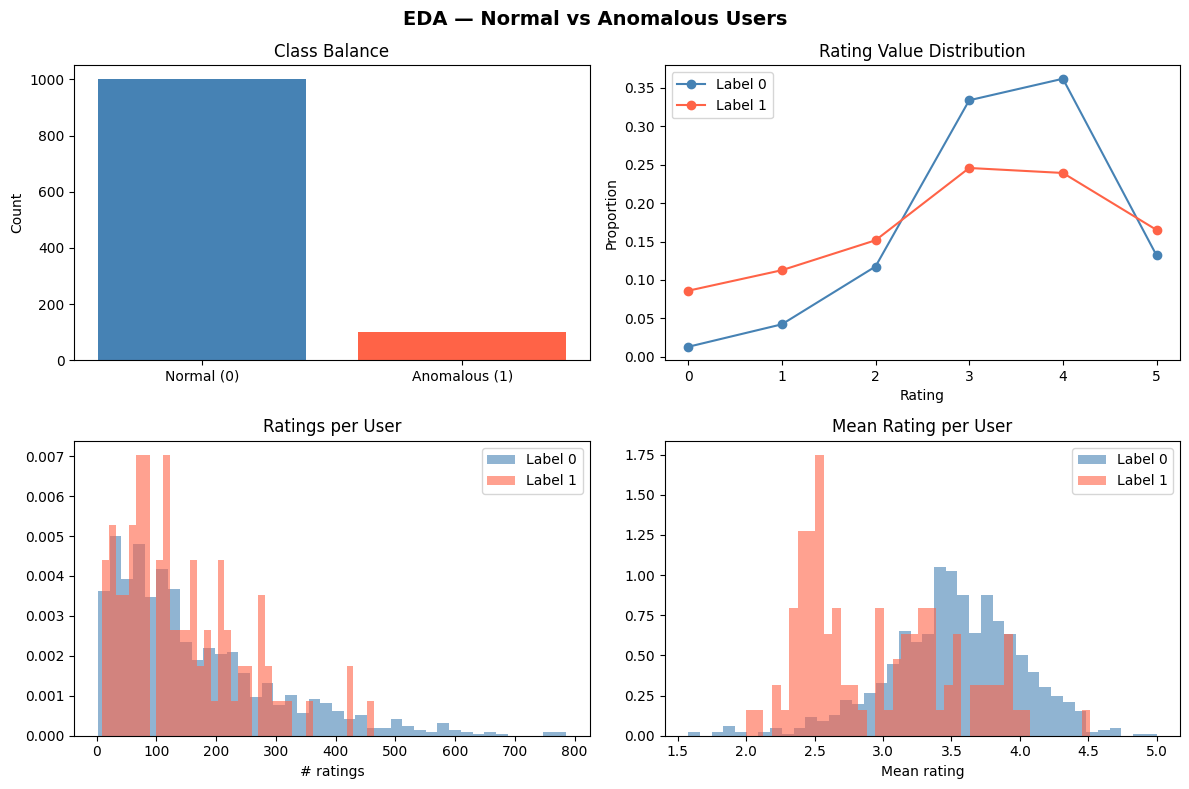

In [49]:
df_ratings = pd.DataFrame(ratings, columns=['user_id', 'item_id', 'rating'])
df_labels  = pd.DataFrame(labels,  columns=['user_id', 'label'])

# Merge so we can split by class
user_activity = (
    df_ratings.groupby('user_id')
    .agg(n_ratings=('rating','count'),
         mean_rating=('rating','mean'),
         std_rating=('rating','std'),
         n_unique_items=('item_id','nunique'))
    .reset_index()
    .merge(df_labels, on='user_id')
)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('EDA — Normal vs Anomalous Users', fontsize=14, fontweight='bold')

# Class balance
axes[0,0].bar(['Normal (0)', 'Anomalous (1)'],
               df_labels['label'].value_counts().sort_index(),
               color=['steelblue', 'tomato'])
axes[0,0].set_title('Class Balance')
axes[0,0].set_ylabel('Count')

# Rating value distribution
for lbl, col in [(0,'steelblue'),(1,'tomato')]:
    uids = df_labels[df_labels['label']==lbl]['user_id']
    vals = df_ratings[df_ratings['user_id'].isin(uids)]['rating'].value_counts().sort_index()
    axes[0,1].plot(vals.index, vals.values/vals.sum(), marker='o', label=f'Label {lbl}', color=col)
axes[0,1].set_title('Rating Value Distribution')
axes[0,1].set_xlabel('Rating')
axes[0,1].set_ylabel('Proportion')
axes[0,1].legend()

# Activity: number of ratings
for lbl, col in [(0,'steelblue'),(1,'tomato')]:
    sub = user_activity[user_activity['label']==lbl]['n_ratings']
    axes[1,0].hist(sub, bins=40, alpha=0.6, color=col, label=f'Label {lbl}', density=True)
axes[1,0].set_title('Ratings per User')
axes[1,0].set_xlabel('# ratings')
axes[1,0].legend()

# Mean rating per user
for lbl, col in [(0,'steelblue'),(1,'tomato')]:
    sub = user_activity[user_activity['label']==lbl]['mean_rating']
    axes[1,1].hist(sub, bins=40, alpha=0.6, color=col, label=f'Label {lbl}', density=True)
axes[1,1].set_title('Mean Rating per User')
axes[1,1].set_xlabel('Mean rating')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('outputs/eda.png', dpi=120)
plt.show()

## 4. Feature Engineering

In [50]:
def build_user_item_matrix(df_ratings, df_labels, n_items=N_ITEMS):
    """
    Returns
    -------
    ui_cat  : pd.DataFrame, shape (n_users, n_items)
              Each cell is a string category: '0','1',...,'5', or 'NI' (no interaction).
              MCA requires categorical / string dtype.
    user_ids: np.array of user IDs (row order)
    """
    user_ids = df_labels['user_id'].values
    uid_to_row = {uid: i for i, uid in enumerate(user_ids)}
    n_users = len(user_ids)

    # Fill matrix with NO_INTERACT sentinel
    mat = np.full((n_users, n_items), NO_INTERACT, dtype=np.int8)

    for _, row in df_ratings.iterrows():
        u = int(row['user_id'])
        i = int(row['item_id'])
        r = int(row['rating'])
        if u in uid_to_row:
            mat[uid_to_row[u], i] = r

    # Convert to string categories for MCA
    cat_map = {0:'0', 1:'1', 2:'2', 3:'3', 4:'4', 5:'5', 6:'NI'}
    mat_str = np.vectorize(cat_map.get)(mat)
    ui_cat  = pd.DataFrame(mat_str, columns=[f'item_{i}' for i in range(n_items)])

    return ui_cat, user_ids


def build_handcrafted_features(df_ratings, df_labels):
    """
    Scalar hand-crafted features per user (for ablation and augmentation).
    """
    uids = df_labels['user_id'].values
    rows = []
    for uid in uids:
        u_df = df_ratings[df_ratings['user_id'] == uid]
        r = u_df['rating'].values
        rows.append(dict(
            user_id          = uid,
            n_ratings        = len(r),
            mean_rating      = r.mean() if len(r) > 0 else 0,
            std_rating       = r.std()  if len(r) > 0 else 0,
            frac_extreme     = np.mean((r == 0) | (r == 5)) if len(r) > 0 else 0,
            frac_five        = np.mean(r == 5) if len(r) > 0 else 0,
            n_unique_items   = u_df['item_id'].nunique(),
            coverage         = u_df['item_id'].nunique() / N_ITEMS,
        ))
    return pd.DataFrame(rows).set_index('user_id').reindex(uids)


print('Building user-item categorical matrix ...')
t0 = time.time()
ui_cat, user_ids = build_user_item_matrix(df_ratings, df_labels)
print(f'  done in {time.time()-t0:.1f}s  shape={ui_cat.shape}')

print('Building hand-crafted features ...')
hc_feats = build_handcrafted_features(df_ratings, df_labels)
print(f'  done  shape={hc_feats.shape}')

y_true = df_labels.set_index('user_id').reindex(user_ids)['label'].values.astype(int)

Building user-item categorical matrix ...
  done in 4.8s  shape=(1100, 1000)
Building hand-crafted features ...
  done  shape=(1100, 7)


## 5. MCA Model

In [ ]:
# ── Hyperparameters ────────────────────────────────────────────────
N_COMPONENTS = 1_000      # MCA latent dimensions
SCORE_MODE   = 'mahalanobis'  # 'euclidean' | 'mahalanobis' | 'reconstruction'

print(f'Fitting MCA with n_components={N_COMPONENTS} ...')
t0 = time.time()

mca = prince.MCA(
    n_components = N_COMPONENTS,
    n_iter       = 10,
    random_state = SEED,
    engine       = 'sklearn',
)
mca.fit(ui_cat)
train_time = time.time() - t0
print(f'  MCA fitted in {train_time:.1f}s')

t1 = time.time()
embeddings = mca.transform(ui_cat).values   # (n_users, N_COMPONENTS)
infer_time = time.time() - t1
print(f'  Transform done in {infer_time:.1f}s  shape={embeddings.shape}')

print(f'  Explained inertia (cumulative): {mca.cumulative_percentage_of_variance_.data[-1]:.2f}%')
mca.eigenvalues_summary

Fitting MCA with n_components=1000 ...
  MCA fitted in 7.4s
  Transform done in 1.3s  shape=(1100, 1000)
  Explained inertia (cumulative): 99.64%


,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,0.183,3.30%,3.30%
1,0.113,2.04%,5.34%
2,0.086,1.56%,6.90%
3,0.082,1.49%,8.39%
4,0.064,1.15%,9.55%
...,...,...,...
995,0.000,0.01%,99.61%
996,0.000,0.01%,99.62%
997,0.000,0.01%,99.62%


In [52]:
mca.row_contributions_.head().style.format('{:.0%}')

In [53]:
mca.column_contributions_.head().style.format('{:.0%}')

## 6. Anomaly Scoring

In [ ]:
def score_euclidean(embeddings):
    """Distance from the MCA origin (centroid)."""
    centroid = embeddings.mean(axis=0, keepdims=True)
    dists    = np.linalg.norm(embeddings - centroid, axis=1)
    return dists


def score_mahalanobis(embeddings):
    """Mahalanobis distance from the centroid in embedding space."""
    centroid = embeddings.mean(axis=0)
    cov      = np.cov(embeddings.T) + 1e-6 * np.eye(embeddings.shape[1])
    cov_inv  = np.linalg.pinv(cov)
    diff     = embeddings - centroid
    dists    = np.sqrt(np.einsum('ij,jk,ik->i', diff, cov_inv, diff))
    return dists


def score_reconstruction(mca, ui_cat):
    """
    Approximate reconstruction error via MCA inverse transform.
    Higher error → more anomalous.
    """
    # MCA inverse: project back to original indicator space
    coords = mca.transform(ui_cat).values
    # Reconstruct in the row principal coordinates space
    # Proxy: distance from the centroid in the full indicator encoding space
    indicator = mca._compute_indicator_matrix(ui_cat)  # binary indicator
    expected  = mca.column_coordinates_   # (n_categories, n_components)

    # Reconstruct expected indicator rows from embedding
    recon     = coords @ mca.column_coordinates_.T    # (n_users, n_cats)
    error     = np.linalg.norm(indicator.toarray() - recon, axis=1)
    return error


def compute_anomaly_scores(raw_scores):
    """Normalise raw distances to [0,1] via min-max, then apply softmax-like sharpening."""
    s = (raw_scores - raw_scores.min()) / (raw_scores.max() - raw_scores.min() + 1e-9)
    return s


# ── Compute scores ─────────────────────────────────────────────────
if SCORE_MODE == 'mahalanobis':
    raw_scores = score_mahalanobis(embeddings)
elif SCORE_MODE == 'euclidean':
    raw_scores = score_euclidean(embeddings)
else:
    raw_scores = score_reconstruction(mca, ui_cat)

anomaly_scores = compute_anomaly_scores(raw_scores)

# ── Evaluation ─────────────────────────────────────────────────────
auc       = roc_auc_score(y_true, anomaly_scores)
threshold = np.percentile(anomaly_scores, 95)   # top 5% flagged as anomalous
y_pred    = (anomaly_scores >= threshold).astype(int)

prec  = precision_score(y_true, y_pred, zero_division=0)
rec   = recall_score(y_true, y_pred, zero_division=0)
f1    = f1_score(y_true, y_pred, zero_division=0)

print(f'AUC       : {auc:.4f}')
print(f'Precision : {prec:.4f}')
print(f'Recall    : {rec:.4f}')
print(f'F1        : {f1:.4f}')

AUC       : 0.6953
Precision : 0.3818
Recall    : 0.2100
F1        : 0.2710


## 7. Evaluation Plots

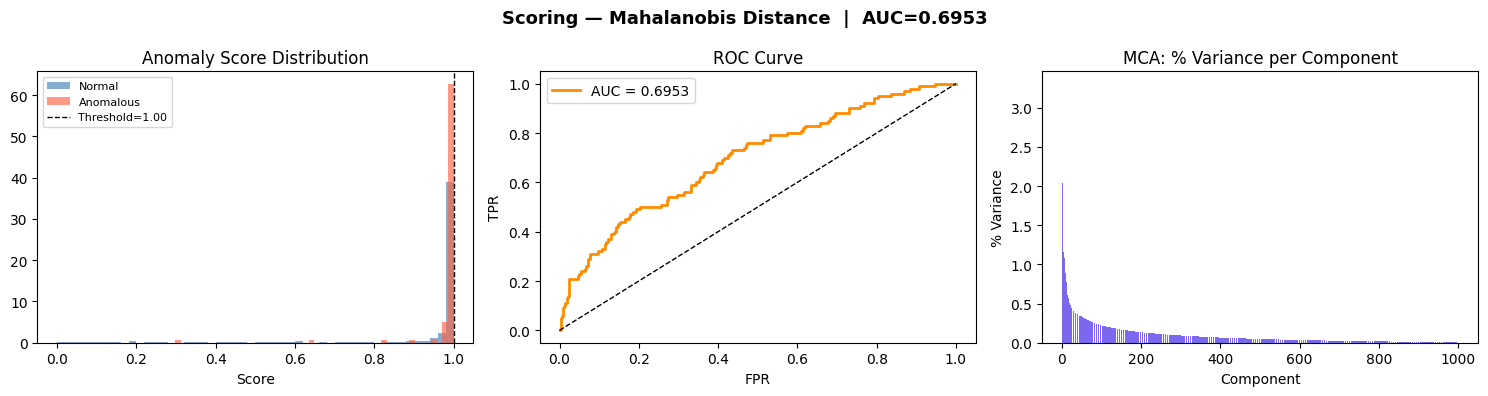

In [55]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'Scoring — {SCORE_MODE.capitalize()} Distance  |  AUC={auc:.4f}', fontsize=13, fontweight='bold')

# Score distribution
for lbl, col, nm in [(0,'steelblue','Normal'),(1,'tomato','Anomalous')]:
    axes[0].hist(anomaly_scores[y_true==lbl], bins=50, alpha=0.65,
                 color=col, label=nm, density=True)
axes[0].axvline(threshold, color='k', linestyle='--', linewidth=1, label=f'Threshold={threshold:.2f}')
axes[0].set_title('Anomaly Score Distribution')
axes[0].set_xlabel('Score')
axes[0].legend(fontsize=8)

# ROC curve
fpr, tpr, _ = roc_curve(y_true, anomaly_scores)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc:.4f}')
axes[1].plot([0,1],[0,1], 'k--', lw=1)
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()

# Explained inertia per component
inertia = mca.percentage_of_variance_
axes[2].bar(range(1, len(inertia)+1), inertia, color='mediumslateblue')
axes[2].set_title('MCA: % Variance per Component')
axes[2].set_xlabel('Component')
axes[2].set_ylabel('% Variance')

plt.tight_layout()
plt.savefig('outputs/evaluation.png', dpi=120)
plt.show()

## 8. Analysis — t-SNE, Ablation & Failure Cases

Running t-SNE on MCA embeddings (this may take a minute) ...


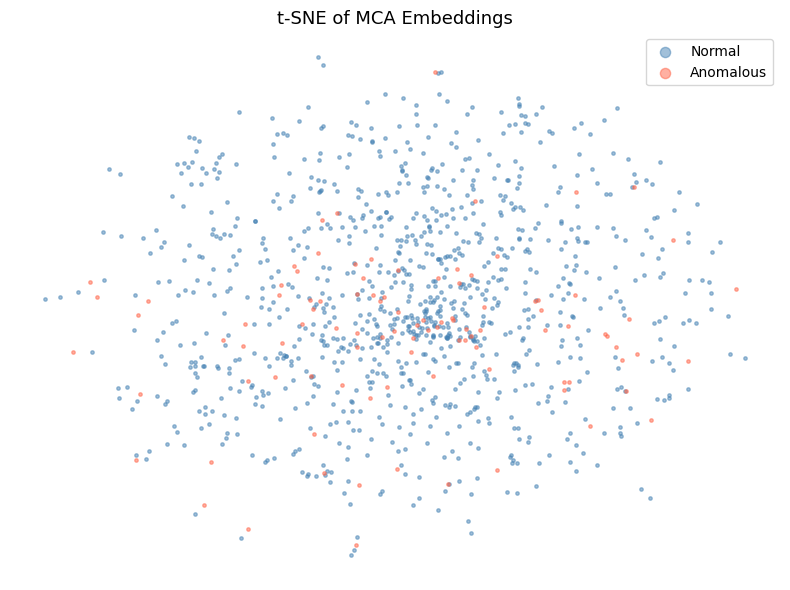

In [56]:
# ── 8a. t-SNE visualisation of MCA embeddings ─────────────────────
print('Running t-SNE on MCA embeddings (this may take a minute) ...')
tsne = TSNE(n_components=2, random_state=SEED, perplexity=40, max_iter=1000)
emb_2d = tsne.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(8, 6))
for lbl, col, nm in [(0,'steelblue','Normal'),(1,'tomato','Anomalous')]:
    mask = y_true == lbl
    ax.scatter(emb_2d[mask,0], emb_2d[mask,1],
               c=col, s=6, alpha=0.5, label=nm)
ax.set_title('t-SNE of MCA Embeddings', fontsize=13)
ax.legend(markerscale=3)
ax.axis('off')
plt.tight_layout()
plt.savefig('outputs/tsne.png', dpi=120)
plt.show()

  euclidean        n_comp=  2  AUC=0.5410
  euclidean        n_comp=  3  AUC=0.5655
  euclidean        n_comp=  4  AUC=0.5683
  euclidean        n_comp=  5  AUC=0.5263
  euclidean        n_comp= 10  AUC=0.5290
  euclidean        n_comp= 20  AUC=0.5427
  euclidean        n_comp= 50  AUC=0.5913
  euclidean        n_comp=100  AUC=0.6138
  euclidean        n_comp=300  AUC=0.6523
  euclidean        n_comp=500  AUC=0.6555
  euclidean        n_comp=750  AUC=0.6610
  euclidean        n_comp=1000  AUC=0.6607
  mahalanobis      n_comp=  2  AUC=0.5732
  mahalanobis      n_comp=  3  AUC=0.5961
  mahalanobis      n_comp=  4  AUC=0.5990
  mahalanobis      n_comp=  5  AUC=0.5208
  mahalanobis      n_comp= 10  AUC=0.5276
  mahalanobis      n_comp= 20  AUC=0.5478
  mahalanobis      n_comp= 50  AUC=0.5924
  mahalanobis      n_comp=100  AUC=0.6184
  mahalanobis      n_comp=300  AUC=0.6556
  mahalanobis      n_comp=500  AUC=0.6690
  mahalanobis      n_comp=750  AUC=0.6877
  mahalanobis      n_comp=1000  A

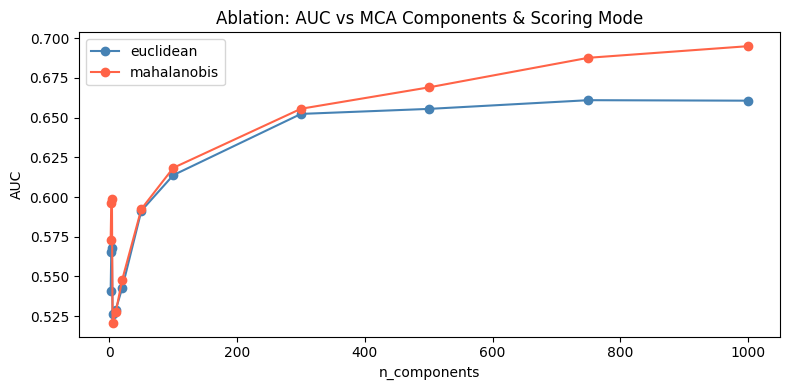

In [57]:
# ── 8b. Ablation study ─────────────────────────────────────────────
# Compare scoring methods, and MCA dimensions vs AUC

ablation_results = []

for mode in ['euclidean', 'mahalanobis']:
    for n_comp in [2, 3, 4, 5, 10, 20, 50, 100, 300, 500, 750, 1000]:
        _mca = prince.MCA(n_components=n_comp, n_iter=5, random_state=SEED, engine='sklearn')
        _mca.fit(ui_cat)
        _emb = _mca.transform(ui_cat).values

        if mode == 'euclidean':
            raw = score_euclidean(_emb)
        else:
            raw = score_mahalanobis(_emb)

        scores_ = compute_anomaly_scores(raw)
        auc_    = roc_auc_score(y_true, scores_)
        ablation_results.append({'mode': mode, 'n_components': n_comp, 'auc': auc_})
        print(f'  {mode:15s}  n_comp={n_comp:3d}  AUC={auc_:.4f}')

df_ablation = pd.DataFrame(ablation_results)

fig, ax = plt.subplots(figsize=(8,4))
for mode, col in [('euclidean','steelblue'),('mahalanobis','tomato')]:
    sub = df_ablation[df_ablation['mode']==mode]
    ax.plot(sub['n_components'], sub['auc'], marker='o', label=mode, color=col)
ax.set_title('Ablation: AUC vs MCA Components & Scoring Mode')
ax.set_xlabel('n_components')
ax.set_ylabel('AUC')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/ablation.png', dpi=120)
plt.show()

True Positives (detected anomalies): 21
False Negatives (missed anomalies) : 79
False Positives (wrongly flagged)  : 34


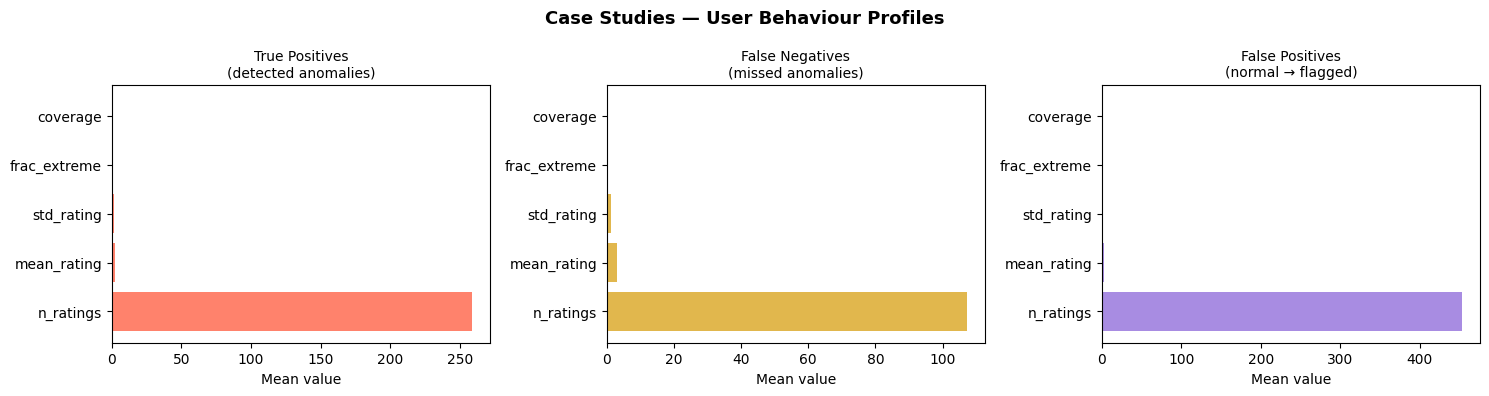

In [58]:
# ── 8c. Case studies — correct detections & failure cases ─────────

df_results = pd.DataFrame({
    'user_id'      : user_ids,
    'label'        : y_true,
    'score'        : anomaly_scores,
    'pred'         : y_pred,
    'correct'      : (y_true == y_pred).astype(int),
}).set_index('user_id').join(hc_feats)

# True positives (correctly detected anomalies)
tp = df_results[(df_results['label']==1) & (df_results['pred']==1)]
# False negatives (missed anomalies)
fn = df_results[(df_results['label']==1) & (df_results['pred']==0)]
# False positives (normal users flagged)
fp = df_results[(df_results['label']==0) & (df_results['pred']==1)]

print(f'True Positives (detected anomalies): {len(tp)}')
print(f'False Negatives (missed anomalies) : {len(fn)}')
print(f'False Positives (wrongly flagged)  : {len(fp)}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Case Studies — User Behaviour Profiles', fontsize=13, fontweight='bold')

for ax, subset, title, col in zip(axes,
                                   [tp, fn, fp],
                                   ['True Positives\n(detected anomalies)',
                                    'False Negatives\n(missed anomalies)',
                                    'False Positives\n(normal → flagged)'],
                                   ['tomato','goldenrod','mediumpurple']):
    if len(subset) == 0:
        ax.text(0.5, 0.5, 'None', ha='center', va='center')
        ax.set_title(title)
        continue
    feats = ['n_ratings','mean_rating','std_rating','frac_extreme','coverage']
    means = subset[feats].mean()
    ax.barh(feats, means, color=col, alpha=0.8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Mean value')

plt.tight_layout()
plt.savefig('outputs/case_studies.png', dpi=120)
plt.show()

In [59]:
# ── 8d. Computational cost analysis ───────────────────────────────

n_users = len(user_ids)
cost_summary = {
    'n_users'           : n_users,
    'n_interactions'    : len(df_ratings),
    'mca_train_time_s'  : round(train_time, 2),
    'mca_infer_time_s'  : round(infer_time, 2),
    'ms_per_user_infer' : round(infer_time / n_users * 1000, 3),
}
print('Computational cost summary:')
for k, v in cost_summary.items():
    print(f'  {k:<25s}: {v}')

Computational cost summary:
  n_users                  : 1100
  n_interactions           : 177346
  mca_train_time_s         : 7.38
  mca_infer_time_s         : 1.32
  ms_per_user_infer        : 1.201


## 9. MLflow Logging

In [60]:
with mlflow.start_run(run_name=f'mca-{SCORE_MODE}-{N_COMPONENTS}comp'):

    # Parameters
    mlflow.log_params({
        'n_components' : N_COMPONENTS,
        'score_mode'   : SCORE_MODE,
        'threshold_pct': 95,
        'seed'         : SEED,
        'data_path'    : DATA_PATH,
    })

    # Metrics
    mlflow.log_metrics({
        'auc'              : auc,
        'precision'        : prec,
        'recall'           : rec,
        'f1'               : f1,
        'train_time_s'     : train_time,
        'infer_time_s'     : infer_time,
        'n_users'          : n_users,
        'n_interactions'   : len(df_ratings),
    })

    # Artifacts
    for artifact in ['outputs/eda.png', 'outputs/evaluation.png',
                     'outputs/tsne.png', 'outputs/ablation.png',
                     'outputs/case_studies.png', 'outputs/submission.npz']:
        mlflow.log_artifact(artifact)

print(f'MLflow run logged.  AUC={auc:.4f}')

🏃 View run mca-mahalanobis-1000comp at: http://localhost:5000/#/experiments/2/runs/33aa555b53f646029f7fec6ac9632a58
🧪 View experiment at: http://localhost:5000/#/experiments/2
MLflow run logged.  AUC=0.6953


## 10. Output — Save Submission

In [61]:
# Build matrix for unlabelled users
df_score_ratings = pd.DataFrame(score_ratings, columns=['user_id', 'item_id', 'rating'])

# Need dummy labels df just to get the user_id list
score_user_ids = np.unique(score_ratings[:, 0].astype(int))
df_score_labels = pd.DataFrame({'user_id': score_user_ids, 'label': -1})

ui_cat_score, score_user_ids_ordered = build_user_item_matrix(df_score_ratings, df_score_labels)

# Transform with the *already fitted* MCA — do not refit
score_embeddings = mca.transform(ui_cat_score).values
raw_score_scores = score_mahalanobis(score_embeddings)   # or whichever mode
submission_scores = compute_anomaly_scores(raw_score_scores)

np.savez('outputs/submission.npz',
         user_ids=score_user_ids_ordered,
         scores=submission_scores)